# Poisson ML Regression

In this notebook, we will implement a ML model to calculate a suitable lambda value for a Poisson distribution modelling number of goals for a team. We will build it using inputs Elo diff and Home advantage.

We will use the 2015/16 and 2016/17 seasons to let the Elo ratings calibrate, and then run the calculation on 2017/18-2022/23. The 2023/24 dataset will be used for validation, and the 2024/25-2025/26 for the final test. At time of production, 2026/27 is in preseason, so data may be excluded.

## Data prep 

We have our Elo calculation in place. We seek to find the relationship via regression between Elo diff, home ad, and expected number of goals. Currently, our Elo calculation produces a final Elo dictionary for each team, so we need to alter the logic to be able to retrieve the Elo before each match.

In [2]:
# data prep
import sqlite3
import pandas as pd
import soccerdata as sd

connection = sqlite3.connect("../data/processed/football.db")

matches = pd.read_sql_query(
    "SELECT * FROM matches",
    connection
)

matches["date"] = pd.to_datetime(matches["date"])
matches = matches.sort_values("date").reset_index(drop=True)

[08/14/26 00:39:12] INFO     No custom team name replacements found. You can configure these in       _config.py:91
                             C:\Users\Rohan\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    _config.py:189
                             C:\Users\Rohan\soccerdata\config\league_dict.json.                                    

In [3]:
# building prior elo inputs
clubelo = sd.ClubElo()

elo_2015 = clubelo.read_by_date("2015-06-30")

countries = ["ENG", "SCO", "GER", "ESP", "ITA", "FRA", "BEL", "NED", "POR", "TUR", "GRE"]

top_leagues = elo_2015[
    (elo_2015["country"].isin(countries)) &
    (elo_2015["level"] == 1)
]

league_elos = top_leagues.groupby("country")["elo"].mean()

league_to_country = {
    "E0": "ENG",
    "SC0": "SCO",
    "D1": "GER",
    "SP1": "ESP",
    "I1": "ITA",
    "F1": "FRA",
    "B1": "BEL",
    "N1": "NED",
    "P1": "POR",
    "T1": "TUR",
    "G1": "GRE"
}

team_leagues = pd.read_sql_query(
    "SELECT DISTINCT team_id, league FROM team_aliases WHERE source = 'football_data'",
    connection
)

                    INFO     Saving cached data to C:\Users\Rohan\soccerdata\data\ClubElo            _common.py:250

[2026-08-14 00:39:12] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: C:\Users\Rohan\Documents\UCL MU Predictor\.venv\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


                    INFO     Successfully loaded TLS library: C:\Users\Rohan\Documents\UCL MU      libraries.py:397
                             Predictor\.venv\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.1                 
                             3.1-windows-amd64.dll                                                                 

In [4]:
# building auxilliary table (key match_id) to matches, with per match elo data (elo before, elo after etc.)
# join to full table, to give full match data with elo 

elo = {}

for _, team in team_leagues.iterrows():

    league = team["league"]
    country = league_to_country[league]

    elo[team["team_id"]] = league_elos.loc[country]


home_elo_before = []
away_elo_before = []

home_elo_after = []
away_elo_after = []

expected_home_scores = []
expected_away_scores = []

K = 20

for _, match in matches.iterrows():

    if match["home_team_id"] not in elo:
        elo[match["home_team_id"]] = 1500

    if match["away_team_id"] not in elo:
        elo[match["away_team_id"]] = 1500

    current_home_rating = elo[match["home_team_id"]]
    current_away_rating = elo[match["away_team_id"]]

    home_elo_before.append(current_home_rating)
    away_elo_before.append(current_away_rating)

    Q_A = 10 ** (current_home_rating / 400)
    Q_B = 10 ** (current_away_rating / 400)

    expected_home_score = Q_A / (Q_A + Q_B)
    expected_away_score = Q_B / (Q_A + Q_B)

    expected_home_scores.append(expected_home_score)
    expected_away_scores.append(expected_away_score)

    if match["home_goals"] > match["away_goals"]:
        S_A = 1
        S_B = 0

    elif match["home_goals"] == match["away_goals"]:
        S_A = 0.5
        S_B = 0.5

    else:
        S_A = 0
        S_B = 1

    updated_home_rating = current_home_rating + K * (S_A - expected_home_score)
    updated_away_rating = current_away_rating + K * (S_B - expected_away_score)

    elo[match["home_team_id"]] = updated_home_rating
    elo[match["away_team_id"]] = updated_away_rating

    home_elo_after.append(updated_home_rating)
    away_elo_after.append(updated_away_rating)


elo_matches = matches.copy()

elo_matches["home_elo_before"] = home_elo_before
elo_matches["away_elo_before"] = away_elo_before

elo_matches["home_elo_after"] = home_elo_after
elo_matches["away_elo_after"] = away_elo_after

elo_matches["expected_home_score"] = expected_home_scores
elo_matches["expected_away_score"] = expected_away_scores

elo_matches["elo_diff"] = (
    elo_matches["home_elo_before"] - elo_matches["away_elo_before"]
)

elo_matches.head()

,match_id,date,season,competition,home_team_id,away_team_id,home_team_name,away_team_name,home_goals,away_goals,source,home_elo_before,away_elo_before,home_elo_after,away_elo_after,expected_home_score,expected_away_score,elo_diff
0,1,2015-06-30,2015/16,CL,14,384,Pyunik,Folgore,2,1,footystats,1500.0,1500.0,1510.0,1490.0,0.5,0.5,0.0
1,2,2015-06-30,2015/16,CL,184,8,Lincoln Red Imps,FC Santa Coloma,0,0,footystats,1500.0,1500.0,1500.0,1500.0,0.5,0.5,0.0
2,3,2015-06-30,2015/16,CL,326,104,Crusaders,Levadia Tallinn,0,0,footystats,1500.0,1500.0,1500.0,1500.0,0.5,0.5,0.0
3,4,2015-07-01,2015/16,CL,106,503,B36 Torshavn,The New Saints,1,2,footystats,1500.0,1500.0,1490.0,1510.0,0.5,0.5,0.0
4,5,2015-07-07,2015/16,CL,8,184,FC Santa Coloma,Lincoln Red Imps,1,2,footystats,1500.0,1500.0,1490.0,1510.0,0.5,0.5,0.0


## Machine Learning - Poisson regression between Elo difference and expected number of goals scored and home advantage

#### Fundamentals:
For each match we make some observations:

For the home team:
1. $d = R_H - R_A$ (elo diff)
2. $h = 1$
3. $Y = \text{home goals}$

For the away team:
1. $d = R_A - R_H$ (elo diff)
2. $h = 0$
3. $Y = \text{away goals}$

Where $R_H$ and $R_A$ are the Elo ratings BEFORE the match.

We make the natural assumption that goals follow the Poisson distribution, that is, 

$$
Y_i \sim \text{Poisson}(\lambda_{i}), \\
\mathbb{P}(Y_i = y) = \frac{e^{-\lambda_{i}}\lambda_{i}^{y}}{y!}
$$

We want to use regression to learn what this $\lambda_{i}$ is. As such, we model it as:

$$
log(\lambda_i) = \beta_0 + \beta_1 d_i + \beta_2 h_i, 
$$
or equivalently,
$$
\lambda_i = \exp{(\beta_0 + \beta_1 d_i + \beta_2 h_i)}.
$$

Here,
- $\beta_0$ is a "baseline" scoring level
- $\beta_1$ is the effect of Elo difference
- $\beta_2$ is the effect of home advantage.

The model chooses the beta's by maximising (calculation handled by a library) the Poisson likelihood (MLE). The formula is:

$$ 
\ell(\beta) = \sum_{i}{y_i log(\lambda_i) - \lambda_i - log(y_{i}!)}.
$$

Then, once fitted, our values can be calculated as 
$$
\lambda_{H} = \exp{(\beta_0 + \beta_1(R_H - R_A) + \beta_2)} \\
\lambda_{A} = \exp{(\beta_0 + \beta_1(R_A - R_H))}
$$

We'll use a library to run the regression for us.

From this, we can then sample integer scores, and implement a simulation of multiple CL tournaments.

### Adding observations to data, priming for regression

We build a home version of the table with suitable home observations, and an away version of the table with suitable away observations, then take the Union

In [5]:
elo_matches.head()

,match_id,date,season,competition,home_team_id,away_team_id,home_team_name,away_team_name,home_goals,away_goals,source,home_elo_before,away_elo_before,home_elo_after,away_elo_after,expected_home_score,expected_away_score,elo_diff
0,1,2015-06-30,2015/16,CL,14,384,Pyunik,Folgore,2,1,footystats,1500.0,1500.0,1510.0,1490.0,0.5,0.5,0.0
1,2,2015-06-30,2015/16,CL,184,8,Lincoln Red Imps,FC Santa Coloma,0,0,footystats,1500.0,1500.0,1500.0,1500.0,0.5,0.5,0.0
2,3,2015-06-30,2015/16,CL,326,104,Crusaders,Levadia Tallinn,0,0,footystats,1500.0,1500.0,1500.0,1500.0,0.5,0.5,0.0
3,4,2015-07-01,2015/16,CL,106,503,B36 Torshavn,The New Saints,1,2,footystats,1500.0,1500.0,1490.0,1510.0,0.5,0.5,0.0
4,5,2015-07-07,2015/16,CL,8,184,FC Santa Coloma,Lincoln Red Imps,1,2,footystats,1500.0,1500.0,1490.0,1510.0,0.5,0.5,0.0


In [6]:
# adding line by line input data (need 2 rows per match H and A)
home_elo_matches = elo_matches.copy()
home_elo_matches['elo_diff'] = home_elo_matches['home_elo_before'] - home_elo_matches['away_elo_before']
home_elo_matches['H'] = 1
home_elo_matches['goals'] = home_elo_matches['home_goals']

away_elo_matches = elo_matches.copy()
away_elo_matches['elo_diff'] = away_elo_matches['away_elo_before'] - away_elo_matches['home_elo_before']
away_elo_matches['H'] = 0
away_elo_matches['goals'] = away_elo_matches['away_goals']

doubled_elo_matches = pd.concat([home_elo_matches, away_elo_matches])

doubled_elo_matches = doubled_elo_matches.sort_values(
    ['date', 'match_id']
)

middle = len(doubled_elo_matches) // 2

display(doubled_elo_matches[middle - 5:middle + 5])

,match_id,date,season,competition,home_team_id,away_team_id,home_team_name,away_team_name,home_goals,away_goals,source,home_elo_before,away_elo_before,home_elo_after,away_elo_after,expected_home_score,expected_away_score,elo_diff,H,goals
20345,20354,2021-02-05,2020/21,SP1,417,443,Alaves,Real Valladolid,1,0,football_data,1711.480788,1726.130603,1721.902194,1715.709197,0.478930,0.521070,14.649814,0,0
20376,20355,2021-02-06,2020/21,B1,29,38,Cercle Brugge,Mechelen,0,1,football_data,1323.414062,1458.923613,1317.127904,1465.209771,0.314308,0.685692,-135.509551,1,0
20376,20355,2021-02-06,2020/21,B1,29,38,Cercle Brugge,Mechelen,0,1,football_data,1323.414062,1458.923613,1317.127904,1465.209771,0.314308,0.685692,135.509551,0,1
20374,20356,2021-02-06,2020/21,B1,40,45,Oostende,Sint-Truiden,3,1,football_data,1409.704710,1423.584540,1420.103992,1413.185258,0.480036,0.519964,-13.879829,1,3
20374,20356,2021-02-06,2020/21,B1,40,45,Oostende,Sint-Truiden,3,1,football_data,1409.704710,1423.584540,1420.103992,1413.185258,0.480036,0.519964,13.879829,0,1
20377,20357,2021-02-06,2020/21,B1,46,41,Standard Liege,Oud-Heverlee Leuven,1,1,football_data,1501.865265,1422.744855,1499.626563,1424.983557,0.611935,0.388065,79.120410,1,1
20377,20357,2021-02-06,2020/21,B1,46,41,Standard Liege,Oud-Heverlee Leuven,1,1,football_data,1501.865265,1422.744855,1499.626563,1424.983557,0.611935,0.388065,-79.120410,0,1
20378,20358,2021-02-06,2020/21,B1,48,31,Waasland-Beveren,Club Brugge,0,2,football_data,1323.372341,1684.390634,1321.147642,1686.615333,0.111235,0.888765,-361.018294,1,0
20378,20358,2021-02-06,2020/21,B1,48,31,Waasland-Beveren,Club Brugge,0,2,football_data,1323.372341,1684.390634,1321.147642,1686.615333,0.111235,0.888765,361.018294,0,2
20379,20359,2021-02-06,2020/21,D1,154,182,Augsburg,Wolfsburg,0,2,football_data,1650.750555,1798.415150,1644.762006,1804.403700,0.299427,0.700573,-147.664595,1,0


In [7]:
# filtering data to what we need

ml_table = doubled_elo_matches.copy()

ml_table = ml_table[
    [
        "match_id",
        "date",
        "season",
        "competition",
        "home_team_name",
        "away_team_name",
        "elo_diff",
        "H",
        "goals"
    ]
]

ml_table = ml_table[
    ml_table["season"].isin([
        "2017/18",
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23",
        "2023/24",
        "2024/25",
        "2025/26"
    ])
]

ml_table = ml_table.sort_values(["date", "match_id", "H"], ascending=[True, True, False]).reset_index(drop=True)

ml_table.head(10)

,match_id,date,season,competition,home_team_name,away_team_name,elo_diff,H,goals
0,7335,2017-06-27,2017/18,CL,Alashkert,FC Santa Coloma,18.929899,1,1
1,7335,2017-06-27,2017/18,CL,Alashkert,FC Santa Coloma,-18.929899,0,0
2,7336,2017-06-27,2017/18,CL,Vikingur Gota,Trepca'89,0.000000,1,2
3,7336,2017-06-27,2017/18,CL,Vikingur Gota,Trepca'89,0.000000,0,1
4,7337,2017-06-27,2017/18,CL,Hibernians,FCI Tallinn,-0.575011,1,2
5,7337,2017-06-27,2017/18,CL,Hibernians,FCI Tallinn,0.575011,0,0
6,7338,2017-06-27,2017/18,CL,The New Saints,Europa FC,15.800917,1,1
7,7338,2017-06-27,2017/18,CL,The New Saints,Europa FC,-15.800917,0,2
8,7339,2017-06-28,2017/18,CL,Linfield,La Fiorita,0.000000,1,1
9,7339,2017-06-28,2017/18,CL,Linfield,La Fiorita,0.000000,0,0


#### Pre verification of existence of trend

Now the data is in place to do so, we can verify that a trend does exist between the two inputs before we run the regression:

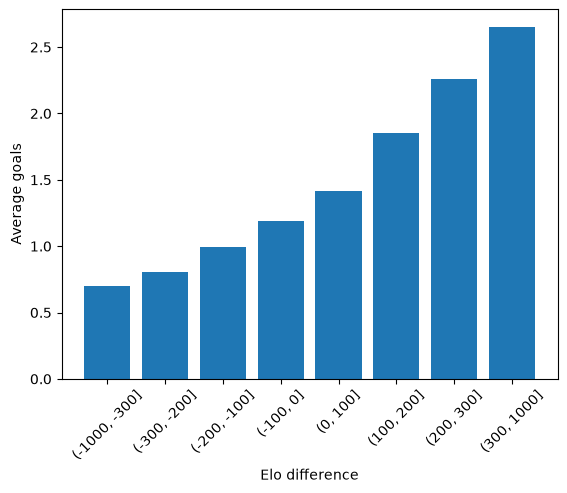

In [25]:
# check dist of goals scored wrt elo diff

import matplotlib.pyplot as plt

plot_table = plot_table = ml_table[
    ml_table["season"].isin([
        "2017/18",
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23"
    ])
].copy()

bins = [-1000, -300, -200, -100, 0, 100, 200, 300, 1000]

plot_table["elo_bucket"] = pd.cut(
    plot_table["elo_diff"],
    bins=bins
)

bucket_goals = plot_table.groupby("elo_bucket", observed=True)["goals"].mean()

plt.bar(bucket_goals.index.astype(str), bucket_goals.values)
plt.xlabel("Elo difference")
plt.ylabel("Average goals")
plt.xticks(rotation=45)
plt.show()

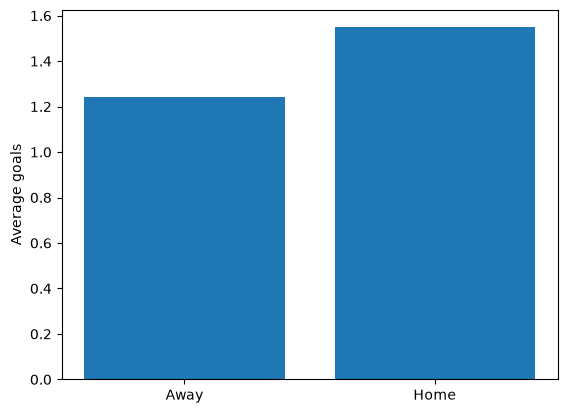

In [9]:
# check relationship between Home ad and goals scored

away_avg = plot_table[plot_table["H"] == 0]["goals"].mean()
home_avg = plot_table[plot_table["H"] == 1]["goals"].mean()

labels = ["Away", "Home"]
avg_goals = [away_avg, home_avg]

plt.bar(labels, avg_goals)
plt.ylabel("Average goals")
plt.show()

In [23]:
# running the regression calculation
# we'll use the statsmodels library (GLM generalised linear model)

import statsmodels.api as sm

train = ml_table[
    ml_table["season"].isin([
        "2017/18",
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23"
    ])
].copy()

X = train[["elo_diff", "H"]] # gives table of elo diff and H (inputs)
y = train["goals"] # gives goals scored (variable being fitted to)

X = sm.add_constant(X) # for baselin beta_0 . starts as 1, and fits through

model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
)

results = model.fit() # fits coefficients

results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                44312
Model:                            GLM   Df Residuals:                    44309
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -64681.
Date:                Fri, 14 Aug 2026   Deviance:                       50414.
Time:                        00:47:55   Pearson chi2:                 4.42e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1356
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1568      0.006     25.335      0.000       0.145       0.169
elo_diff       0.0021   2.76e-05     75.710      0.000       0.002       0.002
H              0.2287      0.008     28.127      0.000       0.213       0.245
==============================================================================
"""

### Explanation of Results:

Model is $\lambda = \exp{(0.1568 + 0.0021d + 0.2287H)}$ \
Easier to read is $$\boxed{\lambda \approx 1.17 \times 1.234^{\frac{d}{100}} \times 1.257^{H}}$$

Therefore:
- an away team playing an equally rated opponent has expected goals of approximately $1.17$
- home advantage multiplies expected goals by approximately $1.257$, or about a $25.7%$ increase
- an equally rated home team therefore has expected goals of approximately $1.17 \times 1.257 \approx 1.47$
- a 100 point Elo advantage multiplies expected goals by approximately $e^{0.21} \approx 1.234$, or about a $23.4\%$ increase

The coefficients are estimated precisely and both Elo difference and home advantage have clear effects. We next evaluate the predictive fit on unseen data.

#### Validation on 2023/24 data

We will validate the quality of fit on the 2023/24 data, and check for poor fits. We start by gathering the 2023/24 data, and inspecting it.

In [11]:
# gather 23/24 data
validation = ml_table[
    ml_table["season"] == "2023/24"
].copy()

X_validation = validation[["elo_diff", "H"]]
X_validation = sm.add_constant(X_validation)

validation["predicted_goals"] = results.predict(X_validation)
display(validation[["elo_diff", "H", "goals", "predicted_goals"]].head(20))

,elo_diff,H,goals,predicted_goals
44312,34.591074,1,0,1.580644
44313,-34.591074,0,3,1.088272
44314,-29.447862,1,1,1.382731
44315,29.447862,0,7,1.244039
44316,-32.753186,1,0,1.373217
44317,32.753186,0,5,1.252658
44318,-78.121089,1,1,1.249054
44319,78.121089,0,1,1.377180
44320,31.803861,1,0,1.571468
44321,-31.803861,0,1,1.094627


We can't see much from this inspection, and individual data points are somewhat meaningless in this context, so we will need some metrics to measure. 

A useful thing to check would be Average predicted goals vs Average actual goals.

In [12]:
# compare actual mean with predicte mean
actual_mean = validation["goals"].mean()
predicted_mean = validation["predicted_goals"].mean()

print("actual mean goals:", actual_mean)
print("predicted mean goals:", predicted_mean)

actual mean goals: 1.450374531835206
predicted mean goals: 1.3925024931779586


The means are sufficiently close that the data is reasonably calibrated on average. However, this tells us nothing about the actual distribution of the data. We want to check that it matches a Poisson suitably. Initially I thought we could compare RMSE between actual goals and predicted goals, but this is not a useful metric, as a lambda of 1.5 and an outcome of 0 is by no means a failure of the model. After some research, I found a metric called Poisson deviance, which is a statistical measure of 'how well a Poisson regression model fits data, calculated as twice the difference in log-likelihood between a saturated model and the fitted model'.

We will use the same library as used for the regression to compute this metric. Generally, closer to 1 is better, however the value requires benchmarking.

To benchmark, we create a Poisson model trained on the same data, which knows nothing of Elo or home ad. That way every team in every match receives the same expected goals (the lambda will esentially just be average goals per team match).

Then we create a Poisson model trained on the same data, which fits for home advantage only. That way we have enough checkts to ensure that both inputs are reducing the Poisson deviance, and hence improving the data fit.

In [13]:
# benchmark 1 - no elo / no home ad, constant expected goals

X_constant = pd.DataFrame(
    {"const": 1},
    index=train.index
)

constant_model = sm.GLM(
    train["goals"],
    X_constant,
    family=sm.families.Poisson()
)

constant_results = constant_model.fit()

X_constant_validation = pd.DataFrame(
    {"const": 1},
    index=validation.index
)

constant_predictions = constant_results.predict(X_constant_validation)

constant_deviance = sm.families.Poisson().deviance(
    validation["goals"],
    constant_predictions
)

constant_mean_deviance = constant_deviance / len(validation)

print("constant beta:", constant_results.params["const"])
print("constant exp goals:", constant_predictions.mean())
print("mean Poisson deviance:", constant_mean_deviance)

constant beta: 0.32375730708633266
constant exp goals: 1.3823117891315064
mean Poisson deviance: 1.2702815717769875


In [14]:
# benchmark 2 - home advantage only

X_home = train[["H"]]
X_home = sm.add_constant(X_home)

home_model = sm.GLM(
    train["goals"],
    X_home,
    family=sm.families.Poisson()
)

home_results = home_model.fit()

X_home_validation = validation[["H"]]
X_home_validation = sm.add_constant(X_home_validation)

home_predictions = home_results.predict(X_home_validation)

home_deviance = sm.families.Poisson().deviance(
    validation["goals"],
    home_predictions
)

home_mean_deviance = home_deviance / len(validation)

print(home_results.params)
print("mean Poisson deviance:", home_mean_deviance)

const    0.205733
H        0.223577
dtype: float64
mean Poisson deviance: 1.2534685351371326


In [15]:
# calculate our models Poisson deviance

poisson_deviance = sm.families.Poisson().deviance(
    validation["goals"],
    validation["predicted_goals"]
)

mean_poisson_deviance = poisson_deviance / len(validation)

print("Mean Poisson deviance:", mean_poisson_deviance)

Mean Poisson deviance: 1.1035800174160022


Results:
Constant only - 1.2703 \
Home only - 1.2535 \
Elo + home - 1.1036 

Thus we can conclude that Elo + home inputs provide a substantial improvement, and shows evidence of the model's predictive value. We can now include 2023/2024 in the training data, and run the same checks on 2024/2025, and repeat for 2025/2026. This will then provide us with (repeated) evidence of the model's predictive power, and we can then proceed with the simulation implementation.

#### Last Check

In [ ]:
# including 23/24 data, check fit against 24/25 data
final_train = ml_table[
    ml_table["season"].isin([
        "2017/18",
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23",
        "2023/24"
    ])
].copy()

test = ml_table[
    ml_table["season"].isin([
        "2024/25",
        "2025/26"
    ])
].copy()

X = final_train[["elo_diff", "H"]]
y = final_train["goals"]

X = sm.add_constant(X)

final_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
)

final_results = final_model.fit()

In [ ]:
# compare means

print("actual mean goals:", test["goals"].mean())
print("predicted mean goals:", test["predicted_goals"].mean())

Actual mean goals: 1.4071352218065205
Predicted mean goals: 1.403075102386378


In [20]:
# compare Poisson deviances 

X_test = test[["elo_diff", "H"]]
X_test = sm.add_constant(X_test)

test["predicted_goals"] = final_results.predict(X_test)

for season in ["2024/25", "2025/26"]:

    season_data = test[test["season"] == season]

    deviance = sm.families.Poisson().deviance(
        season_data["goals"],
        season_data["predicted_goals"]
    )

    mean_deviance = deviance / len(season_data)

    print(season, mean_deviance)


deviance = sm.families.Poisson().deviance(
    test["goals"],
    test["predicted_goals"]
)

mean_deviance = deviance / len(test)

print("combined 24/25 & 25/26 deviance", mean_deviance)

2024/25 1.1266484509855674
2025/26 1.1241706958280193
combined 24/25 & 25/26 deviance 1.12541487058511


### Final Model

We have verified that

1. On average, the model is well calibrated
2. The inputs provide the model with predictive power

Hence, we will run the fit one last time, including all seasons from 2016/2017 up to 2025/2026. 

In [24]:
# final model using all historical data

full_train = ml_table.copy()

X = full_train[["elo_diff", "H"]]
y = full_train["goals"]

X = sm.add_constant(X)

forecast_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
)

forecast_results = forecast_model.fit()

forecast_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                66756
Model:                            GLM   Df Residuals:                    66753
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -97662.
Date:                Fri, 14 Aug 2026   Deviance:                       75498.
Time:                        00:48:06   Pearson chi2:                 6.60e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1349
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1691      0.005     33.732      0.000       0.159       0.179
elo_diff       0.0020   2.17e-05     92.730      0.000       0.002       0.002
H              0.2247      0.007     34.078      0.000       0.212       0.238
==============================================================================
"""